# Candy Classification — Feature Extraction & Clustering

This notebook picks up after segmentation: you should already have, for each photo,

- a cropped RGB image in `data_cropped/`
- a label mask (one integer per candy, `0` = background) produced by
  napari-stardist, napari-cellpose, or napari-accelerated-object-classification,
  saved in `masks/`

**The three candy classes** you're sorting have quite different, quantifiable
signatures:

| class | shape | color pattern |
|---|---|---|
| 🐛 long worms | elongated (high aspect ratio, low circularity) | fade between **2** colors along the body → high within-candy color variation |
| 🔵 Haribo picoballa | small, oval | **3** distinct colors (border + 2 fillings) → high within-candy color variation |
| 🍬 M&Ms | round | **1** solid color → low within-candy color variation |

So **shape** alone can't separate picoballa from M&Ms (both round-ish), and
**color variation** alone can't separate worms from picoballa (both multi-colored) —
but shape *and* color-heterogeneity *together* should cleanly separate all three.
Within the M&M class, the candies differ only by which single color they are, so a
second, finer clustering step on hue can recover the M&M color subtypes. This
"coarse type, then fine subtype within a type" structure is the same idea as
annotating cell types and then cell substates/markers in single-cell image analysis.

**A resolution wrinkle:** Cellpose segmented best on heavily downsampled (224×224)
images, so `masks/` is 224×224 — much lower resolution than the original photos in
`data_raw/`. That's fine for *shape* (the segmentation can't reveal detail it never
had), but it means the intensity features in the earlier version of this notebook,
extracted from the same 224×224 crop, were also lower-fidelity than they needed to be.
Below, we recompute intensity/color features from the **original, non-downsampled**
photos by nearest-neighbor—upsampling the mask back up to match — while keeping shape
features at the mask's native resolution.

We also calibrate pixel measurements into real-world units (cm), using the fact that
the black backing paper is a known **18×18 cm** square — the same idea as a microscope's
pixel size / scale bar.

**Pipeline in this notebook:**

1. Pair up each mask with its cropped RGB image and original raw photo
2. Extract **shape** features from the mask, calibrated to physical units (`skimage.measure.regionprops`)
3. Extract **intensity/color** features from the original-resolution photos (upsampled mask)
4. Explore the resulting feature table
5. **Classify into the 3 candy types** (worm / picoballa / M&M) using shape +
   color-heterogeneity features
6. **Sub-classify the M&Ms by color** using hue

> **Naming convention note:** the code below matches mask files to images by stripping a
> known suffix (e.g. `_cp_masks` for Cellpose) from the mask filename. If you used
> napari-stardist or napari-accelerated-object-classification and it saves masks with a
> different suffix, add it to `MASK_SUFFIXES` below.


In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")  # avoids a noisy sklearn/Windows warning

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skimage import io, color
from skimage.color import rgb2hsv
from skimage.measure import regionprops_table
from skimage.transform import resize as sk_resize
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from prepare_data import detect_black_square_bbox  # reuse the exact same crop-detection logic

sns.set_theme(style="whitegrid")

CROP_DIR = Path("data_cropped")
MASK_DIR = Path("masks")
RAW_DIR = Path("data_raw")

# Add to this list if your segmentation tool uses a different mask filename suffix.
MASK_SUFFIXES = ["_cp_masks", "_stardist_masks", "_masks", "_labels", "_seg"]

PAPER_SIZE_CM = 17.0  # real-world side length of the black backing square


## 1. Pair up masks with their cropped RGB image and original raw photo

In [2]:
def image_base_name(mask_path: Path) -> str:
    """Strip a known mask suffix off a mask filename to recover the image stem."""
    stem = mask_path.stem
    for suffix in MASK_SUFFIXES:
        if stem.endswith(suffix):
            return stem[: -len(suffix)]
    return stem


def find_image_for_mask(mask_path: Path) -> Path:
    base = image_base_name(mask_path)
    matches = list(CROP_DIR.glob(f"{base}.*"))
    if not matches:
        raise FileNotFoundError(f"No cropped image found in {CROP_DIR} for mask {mask_path.name}")
    return matches[0]


def find_raw_for_mask(mask_path: Path) -> Path:
    base = image_base_name(mask_path)
    matches = list(RAW_DIR.glob(f"{base}.*"))
    if not matches:
        raise FileNotFoundError(f"No raw photo found in {RAW_DIR} for mask {mask_path.name}")
    return matches[0]


mask_paths = sorted(MASK_DIR.glob("*.png")) + sorted(MASK_DIR.glob("*.tif*"))
pairs = [(mask_path, find_image_for_mask(mask_path)) for mask_path in mask_paths]

print(f"Found {len(pairs)} mask/image pairs:")
for mask_path, image_path in pairs:
    print(f"  {mask_path.name}  <->  {image_path.name}")


Found 22 mask/image pairs:
  IMG_20260703_084754962_cp_masks.png  <->  IMG_20260703_084754962.jpg
  IMG_20260703_084843178_cp_masks.png  <->  IMG_20260703_084843178.jpg
  IMG_20260703_084945604_cp_masks.png  <->  IMG_20260703_084945604.jpg
  IMG_20260703_085027737_cp_masks.png  <->  IMG_20260703_085027737.jpg
  IMG_20260706_150950073_cp_masks.png  <->  IMG_20260706_150950073.jpg
  IMG_20260706_150958053_cp_masks.png  <->  IMG_20260706_150958053.jpg
  IMG_20260706_151002608_cp_masks.png  <->  IMG_20260706_151002608.jpg
  IMG_20260706_151008218_cp_masks.png  <->  IMG_20260706_151008218.jpg
  IMG_20260706_151013169_cp_masks.png  <->  IMG_20260706_151013169.jpg
  IMG_20260706_151019151_cp_masks.png  <->  IMG_20260706_151019151.jpg
  IMG_20260706_151054957_cp_masks.png  <->  IMG_20260706_151054957.jpg
  IMG_20260706_151101125_cp_masks.png  <->  IMG_20260706_151101125.jpg
  IMG_20260706_151111612_cp_masks.png  <->  IMG_20260706_151111612.jpg
  IMG_20260706_151117344_cp_masks.png  <->  IMG_20

IMG_20260703_084754962.jpg: image shape (224, 224, 3), mask shape (224, 224), 56 candies detected


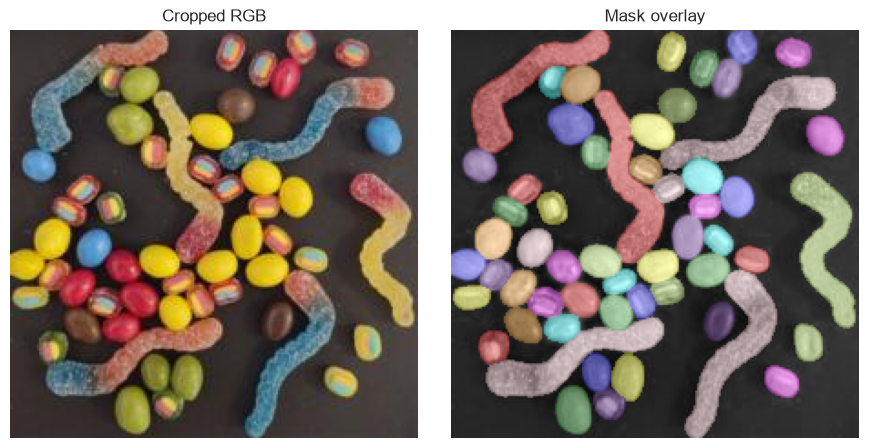

In [3]:
# Quick visual sanity check on the first pair
mask_path, image_path = pairs[0]
mask = io.imread(mask_path)
image = io.imread(image_path)

n_candies = mask.max()
print(f"{image_path.name}: image shape {image.shape}, mask shape {mask.shape}, {n_candies} candies detected")

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(image)
axes[0].set_title("Cropped RGB")
axes[1].imshow(color.label2rgb(mask, image=image, bg_label=0))
axes[1].set_title("Mask overlay")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


## 2. Extract shape features from the masks (calibrated to cm)

`regionprops_table` automatically skips background (label `0`) and gives us one row per
candy.

`prepare_data.py` detects the black paper square and resizes *that exact region* to
224×224 before segmentation — so, as long as the square was detected correctly, 224
pixels always corresponds to the same 18 cm, for every photo. That makes calibration a
single constant: `PAPER_SIZE_CM / 224` cm per pixel. We pass this as the `spacing`
argument to `regionprops_table`, which converts `area` to cm², and lengths
(`perimeter`, `major_axis_length`, `minor_axis_length`, `equivalent_diameter_area`) to
cm directly — the same role a pixel-size/scale-bar calibration plays for a microscope
image.


In [4]:
CM_PER_PIXEL_MASK = PAPER_SIZE_CM / 224  # mask resolution is fixed at 224x224 by prepare_data.py

SHAPE_PROPERTIES = [
    "label",
    "area",
    "perimeter",
    "equivalent_diameter_area",
    "major_axis_length",
    "minor_axis_length",
    "eccentricity",
    "solidity",
    "extent",
    "orientation",
    "bbox",
]

shape_tables = []
for mask_path, image_path in pairs:
    mask = io.imread(mask_path)
    table = regionprops_table(
        mask,
        properties=SHAPE_PROPERTIES,
        spacing=(CM_PER_PIXEL_MASK, CM_PER_PIXEL_MASK),
    )
    df = pd.DataFrame(table)
    df.insert(0, "source_image", image_path.stem)
    shape_tables.append(df)

shape_df = pd.concat(shape_tables, ignore_index=True)

# Dimensionless shape descriptors -- ratios of two lengths/areas, so calibration units
# cancel out and these come out the same whether measured in cm or pixels:
shape_df["circularity"] = 4 * np.pi * shape_df["area"] / shape_df["perimeter"] ** 2
shape_df["aspect_ratio"] = shape_df["major_axis_length"] / shape_df["minor_axis_length"]

print(f"area is now in cm^2, lengths in cm (1 mask pixel = {CM_PER_PIXEL_MASK*10:.3f} mm)")
shape_df.head()


area is now in cm^2, lengths in cm (1 mask pixel = 0.804 mm)


,source_image,label,area,perimeter,equivalent_diameter_area,major_axis_length,minor_axis_length,eccentricity,solidity,extent,orientation,bbox-0,bbox-1,bbox-2,bbox-3,circularity,aspect_ratio
0,IMG_20260703_084754962,1,10.331633,19.776507,3.626933,8.681383,2.559173,0.955562,0.643087,0.305577,-0.890317,0,11,68,88,0.331955,3.392261
1,IMG_20260703_084754962,2,1.711177,4.730630,1.476055,1.603883,1.364423,0.525652,0.956679,0.779412,0.191899,0,151,20,168,0.960875,1.175503
2,IMG_20260703_084754962,3,1.769292,4.891344,1.500911,1.817925,1.240860,0.730821,0.961404,0.778409,-0.269079,1,113,23,129,0.929294,1.465052
3,IMG_20260703_084754962,4,1.711177,4.730630,1.476055,1.647897,1.322864,0.596303,0.956679,0.779412,1.436384,4,178,21,198,0.960875,1.245704
4,IMG_20260703_084754962,5,1.672433,4.891344,1.459249,1.784078,1.205484,0.737186,0.941818,0.725490,-0.365488,11,131,32,148,0.878420,1.479969


## 3. Extract intensity/color features from the original-resolution photos

The masks are only 224×224 because that's what worked best for Cellpose, but the RGB
detail available for measuring *color* is not limited by that — the original photos in
`data_raw/` have much finer detail that was smoothed away when `prepare_data.py`
anti-alias-resized the crop down to 224×224.

We can recover that detail for intensity purposes (though not for shape — see the note
below) by:

1. re-detecting the same paper-square crop from the raw photo (reusing
   `detect_black_square_bbox` from `prepare_data.py`, so it's the exact same square,
   just not resized down),
2. **nearest-neighbor** upsampling the 224×224 mask to match that crop's resolution
   (`order=0`, no interpolation — a candy's label is categorical, so blending label IDs
   between neighbors would be meaningless), and
3. measuring intensity on the full-resolution crop using that upsampled mask.

First, let's see whether this is actually worth the extra step, by comparing against
the cheaper baseline (features straight from the 224×224 crop).


In [5]:
INTENSITY_PROPERTIES = ["label", "intensity_mean", "intensity_std", "intensity_min", "intensity_max"]
CHANNEL_NAMES = ["R", "G", "B"]


def extract_intensity_features(mask: np.ndarray, image: np.ndarray) -> pd.DataFrame:
    channel_dfs = []
    for c, channel_name in enumerate(CHANNEL_NAMES):
        table = regionprops_table(mask, intensity_image=image[..., c], properties=INTENSITY_PROPERTIES)
        df = pd.DataFrame(table).set_index("label")
        channel_dfs.append(df.add_prefix(f"{channel_name}_"))
    return pd.concat(channel_dfs, axis=1).reset_index()


# Baseline: straight from the 224x224 crop (fast, lower fidelity)
baseline_tables = []
for mask_path, image_path in pairs:
    mask = io.imread(mask_path)
    image = io.imread(image_path)
    df = extract_intensity_features(mask, image)
    df.insert(0, "source_image", image_path.stem)
    baseline_tables.append(df)
intensity_df_baseline = pd.concat(baseline_tables, ignore_index=True)
intensity_df_baseline.head()


,source_image,label,R_intensity_mean,R_intensity_std,R_intensity_min,R_intensity_max,G_intensity_mean,G_intensity_std,G_intensity_min,G_intensity_max,B_intensity_mean,B_intensity_std,B_intensity_min,B_intensity_max
0,IMG_20260703_084754962,1,124.560625,43.169174,6.0,213.0,119.221875,25.563845,14.0,172.0,116.848125,33.561903,0.0,190.0
1,IMG_20260703_084754962,2,170.120755,34.670097,72.0,248.0,116.467925,41.201116,18.0,187.0,104.890566,33.311555,31.0,180.0
2,IMG_20260703_084754962,3,154.784672,43.561698,58.0,255.0,109.029197,39.715952,29.0,187.0,97.653285,34.616147,31.0,178.0
3,IMG_20260703_084754962,4,153.516981,39.317199,66.0,243.0,108.086792,39.401130,25.0,185.0,96.267925,32.785177,23.0,170.0
4,IMG_20260703_084754962,5,148.745174,41.719008,54.0,234.0,107.119691,42.525182,4.0,182.0,96.189189,36.875965,12.0,197.0


In [6]:
def upsample_mask_nn(mask: np.ndarray, target_shape: tuple) -> np.ndarray:
    return sk_resize(mask, target_shape, order=0, preserve_range=True, anti_aliasing=False).astype(mask.dtype)


def get_fullres_crop(mask_path: Path) -> np.ndarray:
    raw = io.imread(find_raw_for_mask(mask_path))
    top, bottom, left, right = detect_black_square_bbox(raw)
    return raw[top:bottom, left:right]


# Improved: upsample the mask, measure on the original-resolution crop
fullres_tables = []
for mask_path, image_path in pairs:
    mask = io.imread(mask_path)
    fullres_crop = get_fullres_crop(mask_path)
    mask_upsampled = upsample_mask_nn(mask, fullres_crop.shape[:2])

    df = extract_intensity_features(mask_upsampled, fullres_crop)
    df.insert(0, "source_image", image_path.stem)
    fullres_tables.append(df)
intensity_df = pd.concat(fullres_tables, ignore_index=True)
intensity_df.head()


,source_image,label,R_intensity_mean,R_intensity_std,R_intensity_min,R_intensity_max,G_intensity_mean,G_intensity_std,G_intensity_min,G_intensity_max,B_intensity_mean,B_intensity_std,B_intensity_min,B_intensity_max
0,IMG_20260703_084754962,1,125.265214,56.718632,0.0,255.0,119.896530,42.388685,0.0,255.0,117.595929,47.427769,0.0,255.0
1,IMG_20260703_084754962,2,173.798018,42.853750,19.0,255.0,116.017572,50.342788,0.0,233.0,103.972519,44.250696,0.0,236.0
2,IMG_20260703_084754962,3,157.543566,54.668221,24.0,255.0,109.004735,51.807769,0.0,224.0,97.002694,47.518930,0.0,219.0
3,IMG_20260703_084754962,4,157.485623,50.627868,17.0,255.0,106.926247,49.610186,0.0,239.0,96.048167,44.552152,0.0,237.0
4,IMG_20260703_084754962,5,150.356126,51.511354,10.0,255.0,107.445587,53.057533,0.0,233.0,95.380091,48.265929,0.0,235.0


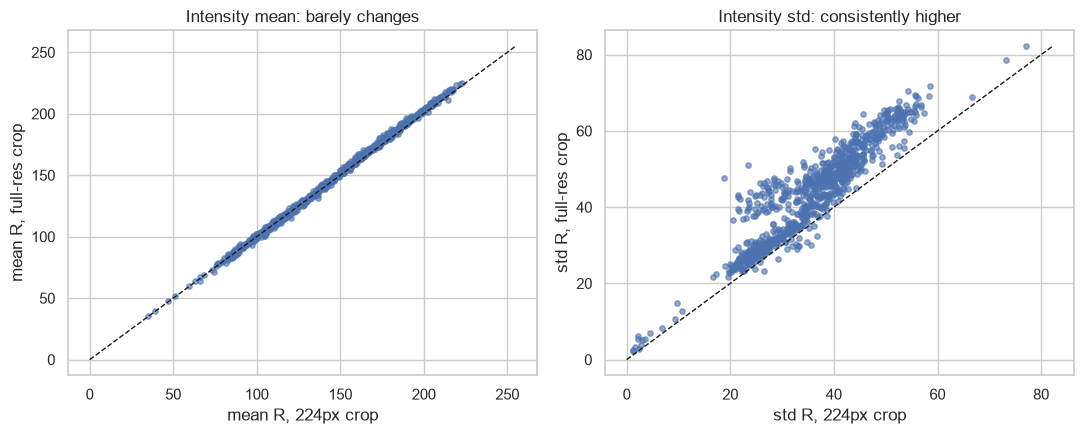

mean intensity correlation (224px vs full-res): 0.999
std intensity correlation (224px vs full-res): 0.930
average std_fullres / std_224px ratio: 1.23x


In [7]:
# Compare: did upsampling actually change anything?
comparison = intensity_df_baseline.merge(
    intensity_df, on=["source_image", "label"], suffixes=("_224px", "_fullres")
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(comparison["R_intensity_mean_224px"], comparison["R_intensity_mean_fullres"], s=15, alpha=0.6)
axes[0].plot([0, 255], [0, 255], "k--", linewidth=1)
axes[0].set_xlabel("mean R, 224px crop")
axes[0].set_ylabel("mean R, full-res crop")
axes[0].set_title("Intensity mean: barely changes")

axes[1].scatter(comparison["R_intensity_std_224px"], comparison["R_intensity_std_fullres"], s=15, alpha=0.6)
lims = [0, max(comparison["R_intensity_std_224px"].max(), comparison["R_intensity_std_fullres"].max())]
axes[1].plot(lims, lims, "k--", linewidth=1)
axes[1].set_xlabel("std R, 224px crop")
axes[1].set_ylabel("std R, full-res crop")
axes[1].set_title("Intensity std: consistently higher")
plt.tight_layout()
plt.show()

mean_corr = comparison["R_intensity_mean_224px"].corr(comparison["R_intensity_mean_fullres"])
std_corr = comparison["R_intensity_std_224px"].corr(comparison["R_intensity_std_fullres"])
std_ratio = (comparison["R_intensity_std_fullres"] / comparison["R_intensity_std_224px"]).mean()
print(f"mean intensity correlation (224px vs full-res): {mean_corr:.3f}")
print(f"std intensity correlation (224px vs full-res): {std_corr:.3f}")
print(f"average std_fullres / std_224px ratio: {std_ratio:.2f}x")


**Interpretation:** average intensity barely changes (resizing preserves means well),
but standard deviation is consistently *higher* at full resolution. The 224×224 resize
uses anti-aliasing (area-averaging), which smooths away exactly the pixel-to-pixel color
variation we're relying on to tell multi-colored candies (worms, picoballa) apart from
solid-colored ones (M&Ms). So the full-resolution version isn't just "more precise" —
it's measuring a real signal the downsampled version was partially washing out. We'll
use it from here on.

**Caveat:** this only helps *intensity* features. Upsampling the mask with
nearest-neighbor doesn't invent new boundary detail — a candy's outline is still exactly
as blocky as it was at 224×224, just drawn bigger. That's why shape features
(section 2) stay computed on the original low-resolution mask.


## 4. Extract color identity (hue) — also from the full-resolution photos

In [8]:
def circular_mean_hue(hue_values: np.ndarray) -> float:
    angles = hue_values * 2 * np.pi
    mean_angle = np.arctan2(np.mean(np.sin(angles)), np.mean(np.cos(angles)))
    return (mean_angle / (2 * np.pi)) % 1.0


hue_rows = []
for mask_path, image_path in pairs:
    mask = io.imread(mask_path)
    fullres_crop = get_fullres_crop(mask_path)
    mask_upsampled = upsample_mask_nn(mask, fullres_crop.shape[:2])
    hsv = rgb2hsv(fullres_crop)
    hue_channel, sat_channel = hsv[..., 0], hsv[..., 1]

    for label in np.unique(mask_upsampled):
        if label == 0:
            continue
        region = mask_upsampled == label
        hue_rows.append(
            {
                "source_image": image_path.stem,
                "label": label,
                "hue_mean": circular_mean_hue(hue_channel[region]),
                "saturation_mean": sat_channel[region].mean(),
            }
        )

hue_df = pd.DataFrame(hue_rows)
hue_df["hue_sin"] = np.sin(hue_df["hue_mean"] * 2 * np.pi)
hue_df["hue_cos"] = np.cos(hue_df["hue_mean"] * 2 * np.pi)
hue_df.head()


,source_image,label,hue_mean,saturation_mean,hue_sin,hue_cos
0,IMG_20260703_084754962,1,0.506621,0.348728,-0.041587,-0.999135
1,IMG_20260703_084754962,2,0.021099,0.441024,0.132179,0.991226
2,IMG_20260703_084754962,3,0.015757,0.429374,0.098844,0.995103
3,IMG_20260703_084754962,4,0.019851,0.426095,0.124403,0.992232
4,IMG_20260703_084754962,5,0.014205,0.426480,0.089134,0.996020


## 5. Combine all features into one table

In [9]:
features_df = shape_df.merge(intensity_df, on=["source_image", "label"]).merge(
    hue_df, on=["source_image", "label"]
)
features_df.insert(0, "candy_id", features_df["source_image"] + "_" + features_df["label"].astype(str))

# Combined color-heterogeneity score: how much a candy's color varies across its own
# area, averaged over the 3 channels. Low = solid color (M&M), high = multi-color
# (worm/picoballa).
features_df["color_std_mean"] = features_df[
    ["R_intensity_std", "G_intensity_std", "B_intensity_std"]
].mean(axis=1)

print(f"{len(features_df)} candies total, across {features_df['source_image'].nunique()} photos")
features_df.head()


881 candies total, across 22 photos


,candy_id,source_image,label,area,perimeter,equivalent_diameter_area,major_axis_length,minor_axis_length,eccentricity,solidity,...,G_intensity_max,B_intensity_mean,B_intensity_std,B_intensity_min,B_intensity_max,hue_mean,saturation_mean,hue_sin,hue_cos,color_std_mean
0,IMG_20260703_084754962_1,IMG_20260703_084754962,1,10.331633,19.776507,3.626933,8.681383,2.559173,0.955562,0.643087,...,255.0,117.595929,47.427769,0.0,255.0,0.506621,0.348728,-0.041587,-0.999135,48.845029
1,IMG_20260703_084754962_2,IMG_20260703_084754962,2,1.711177,4.730630,1.476055,1.603883,1.364423,0.525652,0.956679,...,233.0,103.972519,44.250696,0.0,236.0,0.021099,0.441024,0.132179,0.991226,45.815745
2,IMG_20260703_084754962_3,IMG_20260703_084754962,3,1.769292,4.891344,1.500911,1.817925,1.240860,0.730821,0.961404,...,224.0,97.002694,47.518930,0.0,219.0,0.015757,0.429374,0.098844,0.995103,51.331640
3,IMG_20260703_084754962_4,IMG_20260703_084754962,4,1.711177,4.730630,1.476055,1.647897,1.322864,0.596303,0.956679,...,239.0,96.048167,44.552152,0.0,237.0,0.019851,0.426095,0.124403,0.992232,48.263402
4,IMG_20260703_084754962_5,IMG_20260703_084754962,5,1.672433,4.891344,1.459249,1.784078,1.205484,0.737186,0.941818,...,233.0,95.380091,48.265929,0.0,235.0,0.014205,0.426480,0.089134,0.996020,50.944939


In [10]:
# Save the feature table so it can be reused without re-running segmentation
features_df.to_csv("candy_features.csv", index=False)


## 6. Explore the data

Before clustering blindly, look at what the features actually look like. In particular,
check whether `aspect_ratio` / `circularity` (shape) and `color_std_mean` (color
heterogeneity) already visually separate three groups — if the biology/physics is as
described, they should.


In [11]:
feature_cols = [c for c in features_df.columns if c not in ("candy_id", "source_image", "label") and not c.startswith("bbox")]

features_df[feature_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
area,881.0,2.730099,2.306455,0.251834,1.672433,1.982382,2.518335,12.372130
perimeter,881.0,6.510934,4.185356,1.967567,4.769625,5.185198,5.875128,23.709276
equivalent_diameter_area,881.0,1.769339,0.588133,0.566255,1.459249,1.588725,1.790655,3.968965
major_axis_length,881.0,2.408858,1.864055,0.918252,1.658665,1.836231,2.051083,10.257021
minor_axis_length,881.0,1.484918,0.357571,0.353416,1.275820,1.406581,1.583219,3.878846
eccentricity,881.0,0.654151,0.147002,0.077897,0.566242,0.648333,0.726710,0.986749
solidity,881.0,0.931429,0.083474,0.532674,0.946154,0.956863,0.965649,0.986188
extent,881.0,0.721396,0.119406,0.223485,0.719298,0.753623,0.783282,0.907268
orientation,881.0,-0.036767,0.900579,-1.567317,-0.831183,-0.060566,0.727534,1.568688
circularity,881.0,0.867528,0.176062,0.178852,0.888860,0.923422,0.947307,1.011457


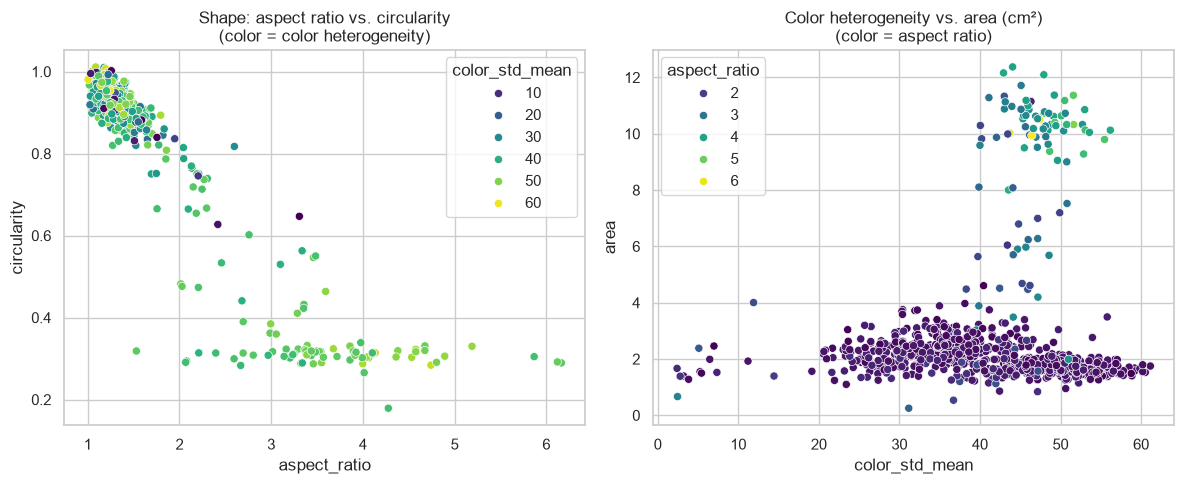

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=features_df, x="aspect_ratio", y="circularity", hue="color_std_mean",
                 palette="viridis", s=35, ax=axes[0])
axes[0].set_title("Shape: aspect ratio vs. circularity\n(color = color heterogeneity)")

sns.scatterplot(data=features_df, x="color_std_mean", y="area", hue="aspect_ratio",
                 palette="viridis", s=35, ax=axes[1])
axes[1].set_title("Color heterogeneity vs. area (cm²)\n(color = aspect ratio)")
plt.tight_layout()
plt.show()


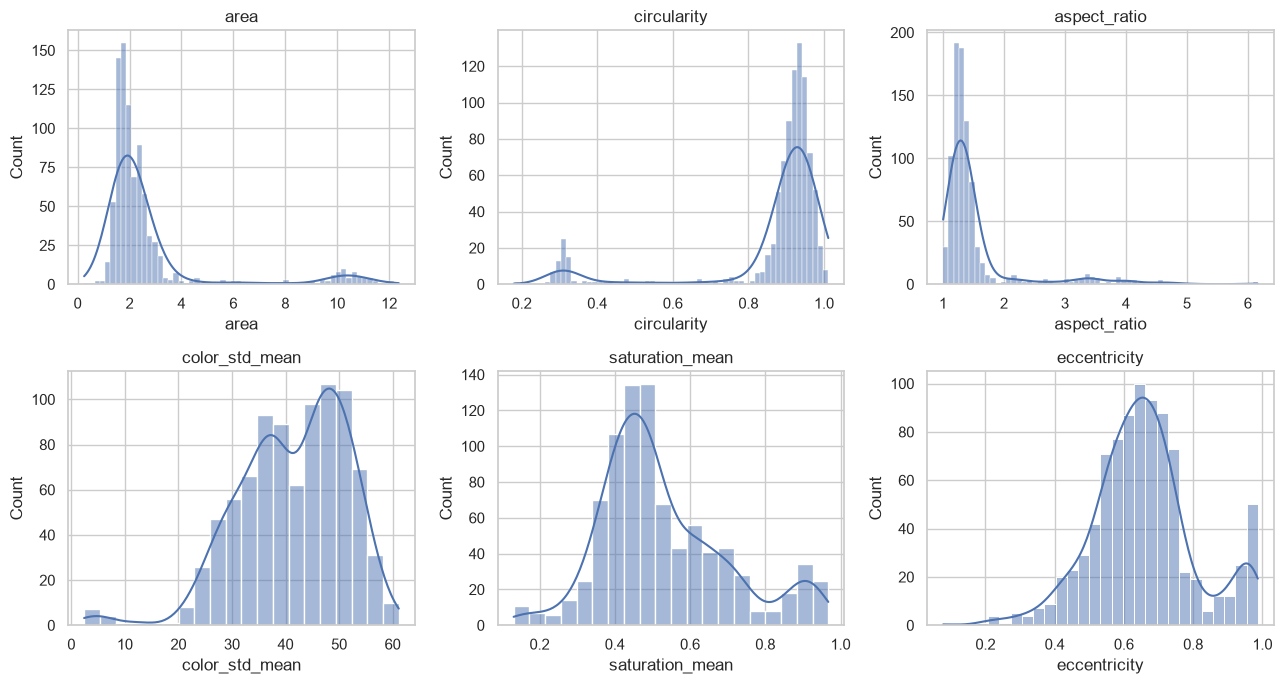

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
plot_cols = ["area", "circularity", "aspect_ratio", "color_std_mean", "saturation_mean", "eccentricity"]
for ax, col in zip(axes.ravel(), plot_cols):
    sns.histplot(features_df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


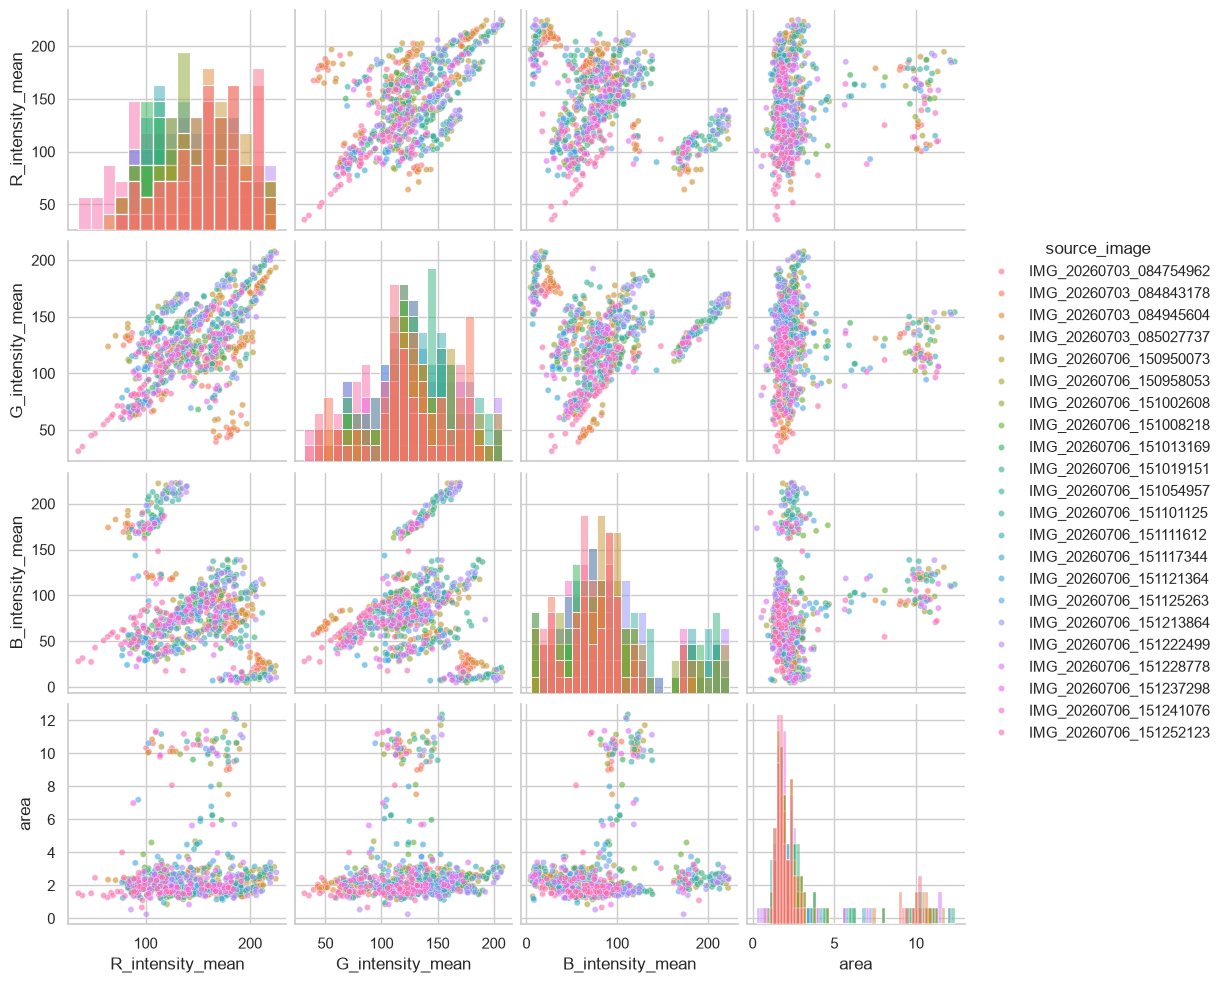

In [14]:
# Do the four photos look similar to each other? Lighting/exposure differences would
# show up here as photo-dependent shifts, which is exactly why we use hue (not raw RGB)
# for the color-identity clustering in section 8.
sns.pairplot(
    features_df,
    vars=["R_intensity_mean", "G_intensity_mean", "B_intensity_mean", "area"],
    hue="source_image",
    diag_kind="hist",
    plot_kws={"alpha": 0.6, "s": 20},
)
plt.show()


## 7. Classify into the 3 candy types

Shape distinguishes worms (elongated) from the two round classes; color heterogeneity
then distinguishes the two round classes from each other (picoballa's 3 colors vs.
M&Ms' 1 color). Deliberately **excluding raw hue/RGB-mean** from this step matters: candy
*type* shouldn't depend on which specific color a candy happens to be, especially since
M&Ms come in many colors.

(Calibrating `area` to cm² instead of raw pixel count doesn't change the clustering
itself — KMeans runs on standardized features, and standardization already removes the
effect of a constant unit-conversion factor. It does make the numbers below directly
interpretable, and lets us sanity-check them against real-world candy sizes.)


C:\Users\annam\Documents\compbiol_git\compbiol\bioimaging\Unit4\.pixi\envs\default\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


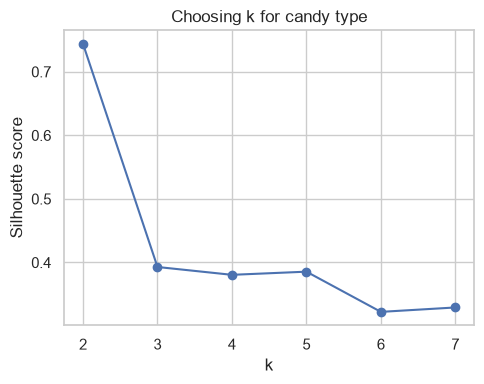

In [15]:
TYPE_FEATURES = ["aspect_ratio", "circularity", "eccentricity", "solidity", "color_std_mean", "area"]

X_type = StandardScaler().fit_transform(features_df[TYPE_FEATURES])

# With only 3 expected classes we can check k=3 is actually a good choice:
k_values = range(2, 8)
silhouettes = [silhouette_score(X_type, KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(X_type)) for k in k_values]

plt.figure(figsize=(5, 4))
plt.plot(list(k_values), silhouettes, "o-")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Choosing k for candy type")
plt.tight_layout()
plt.show()


In [16]:
N_TYPES = 3  # worm / picoballa / M&M

type_kmeans = KMeans(n_clusters=N_TYPES, n_init=10, random_state=0)
features_df["type_cluster"] = type_kmeans.fit_predict(X_type)

type_means = features_df.groupby("type_cluster")[TYPE_FEATURES].mean().round(2)
print(features_df["type_cluster"].value_counts().sort_index())
type_means


type_cluster
0    401
1    398
2     82
Name: count, dtype: int64


,aspect_ratio,circularity,eccentricity,solidity,color_std_mean,area
type_cluster,,,,,,
0,1.34,0.92,0.63,0.96,49.24,1.81
1,1.32,0.92,0.61,0.96,32.32,2.29
2,3.56,0.34,0.95,0.68,46.94,9.38


Now we translate cluster numbers into candy names. This mirrors annotating clusters by
marker expression in single-cell analysis: we don't hand-label individual candies, we
inspect each cluster's *aggregate* profile and assign an identity to the whole cluster.

- **worm**: by far the highest `aspect_ratio` (elongated) among the three clusters
- **M&M**: of the two remaining (round) clusters, the one with lower `color_std_mean`
  (single solid color)
- **picoballa**: whatever is left (round, higher `color_std_mean` from its 3 colors)

Always cross-check this against the printed `type_means` table and the example-crop
grid below before trusting it — the heuristic assumes each candy type actually formed
its own cluster.


In [17]:
worm_id = type_means["aspect_ratio"].idxmax()
remaining = type_means.drop(index=worm_id)
mm_id = remaining["color_std_mean"].idxmin()
picoballa_id = remaining.drop(index=mm_id).index[0]

cluster_to_name = {worm_id: "worm", mm_id: "m&m", picoballa_id: "picoballa"}
features_df["candy_type"] = features_df["type_cluster"].map(cluster_to_name)

features_df["candy_type"].value_counts()


candy_type
picoballa    401
m&m          398
worm          82
Name: count, dtype: int64

**Physical sanity check:** a real M&M is about 13 mm in diameter. If the calibration
(section 2) and the paper-square detection are both correct, the `m&m` cluster's
`equivalent_diameter_area` below should come out close to that — a very direct way to
catch a broken calibration (e.g. `detect_black_square_bbox` including some of the outer
mat, which would make every physical measurement too large).


In [18]:
diameter_mm_by_type = (features_df.groupby("candy_type")["equivalent_diameter_area"].mean() * 10).round(1)
diameter_mm_by_type.rename("mean equivalent diameter (mm)")


candy_type
m&m          16.9
picoballa    15.1
worm         34.2
Name: mean equivalent diameter (mm), dtype: float64

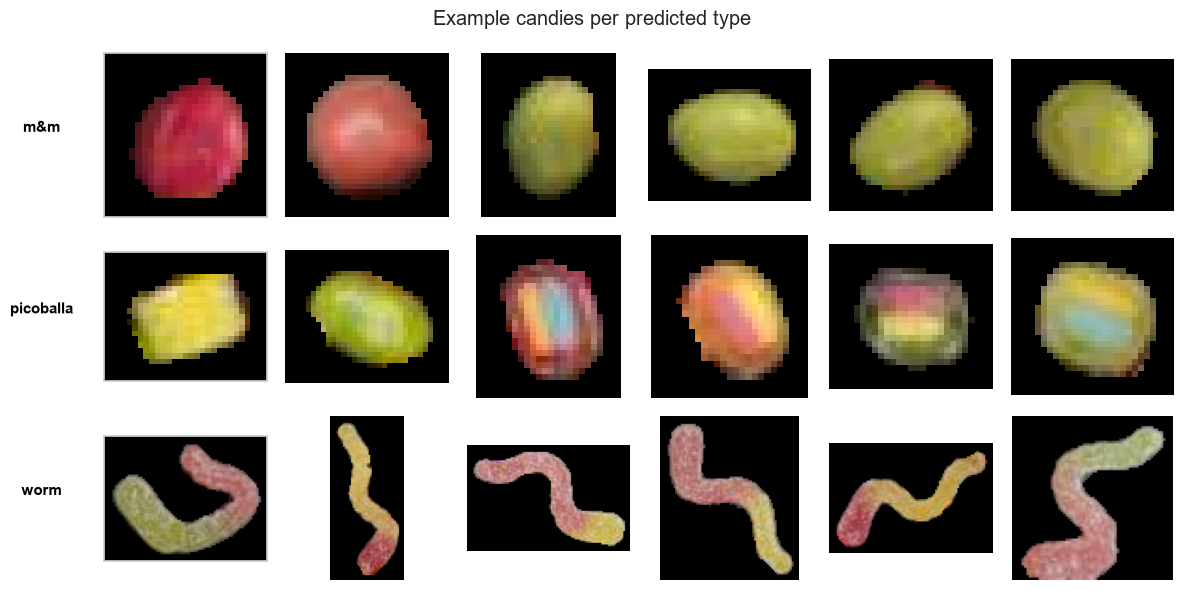

In [19]:
def crop_candy(source_image: str, label: int, bbox_margin: int = 4):
    image_path = next(CROP_DIR.glob(f"{source_image}.*"))
    mask_path = next(p for p, i in pairs if image_base_name(p) == source_image)
    image = io.imread(image_path)
    mask = io.imread(mask_path)

    ys, xs = np.where(mask == label)
    y0, y1 = max(ys.min() - bbox_margin, 0), min(ys.max() + bbox_margin, mask.shape[0])
    x0, x1 = max(xs.min() - bbox_margin, 0), min(xs.max() + bbox_margin, mask.shape[1])

    crop = image[y0:y1, x0:x1].copy()
    crop[mask[y0:y1, x0:x1] != label] = 0  # blank out neighboring candies in the crop
    return crop


def show_examples_by_group(df, group_col, n_examples=6, title=None, label_colors=None):
    """label_colors: optional {group_value: (r, g, b)} to color each row's label,
    e.g. with that cluster's own mean color instead of an arbitrary one."""
    groups = sorted(df[group_col].unique(), key=str)
    fig, axes = plt.subplots(len(groups), n_examples, figsize=(2 * n_examples, 2 * len(groups)))
    axes = np.atleast_2d(axes)
    for row_i, group_value in enumerate(groups):
        subset = df[df[group_col] == group_value]
        examples = subset.sample(min(n_examples, len(subset)), random_state=0)
        for col_i in range(n_examples):
            ax = axes[row_i, col_i]
            ax.axis("off")
            if col_i < len(examples):
                row = examples.iloc[col_i]
                ax.imshow(crop_candy(row["source_image"], row["label"]))
            if col_i == 0:
                label_color = label_colors[group_value] if label_colors else "black"
                ax.set_ylabel(str(group_value), rotation=0, labelpad=45, fontsize=11,
                               color=label_color, fontweight="bold")
                ax.axis("on")
                ax.set_xticks([])
                ax.set_yticks([])
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show_examples_by_group(features_df, "candy_type", title="Example candies per predicted type")


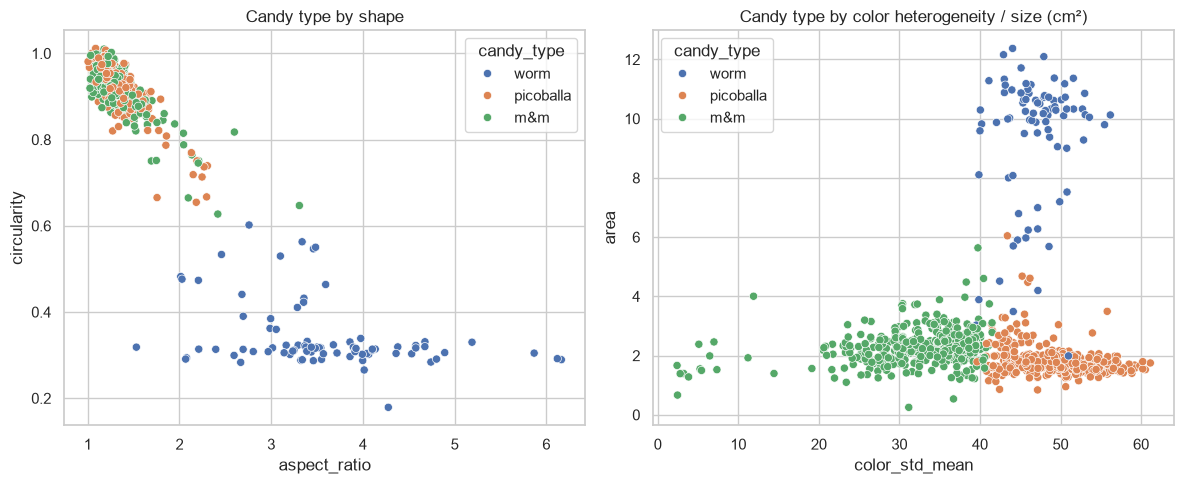

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=features_df, x="aspect_ratio", y="circularity", hue="candy_type", s=35, ax=axes[0])
axes[0].set_title("Candy type by shape")
sns.scatterplot(data=features_df, x="color_std_mean", y="area", hue="candy_type", s=35, ax=axes[1])
axes[1].set_title("Candy type by color heterogeneity / size (cm²)")
plt.tight_layout()
plt.show()


## 8. Sub-classify the M&Ms by color

Within the M&M cluster, every candy has (by construction) roughly the same shape and
low color heterogeneity — the only thing left to distinguish them is *which* color they
are. We cluster on `hue_sin`/`hue_cos` (+ saturation) rather than raw RGB so that
lighting differences between the 4 photos don't get confused with genuine color
differences (see the pairplot in section 6).

This is the "subtype within a type" step: the same clustering machinery, applied only
within one previously-identified group, at a finer resolution.


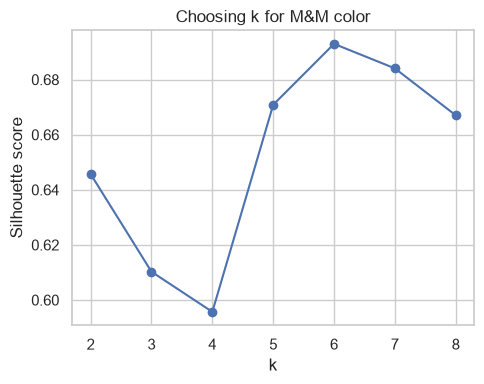

In [21]:
mm_df = features_df[features_df["candy_type"] == "m&m"].copy()
COLOR_FEATURES = ["hue_sin", "hue_cos", "saturation_mean"]

X_color = StandardScaler().fit_transform(mm_df[COLOR_FEATURES])

k_values = range(2, 9)
silhouettes = [silhouette_score(X_color, KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(X_color)) for k in k_values]

plt.figure(figsize=(5, 4))
plt.plot(list(k_values), silhouettes, "o-")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Choosing k for M&M color")
plt.tight_layout()
plt.show()


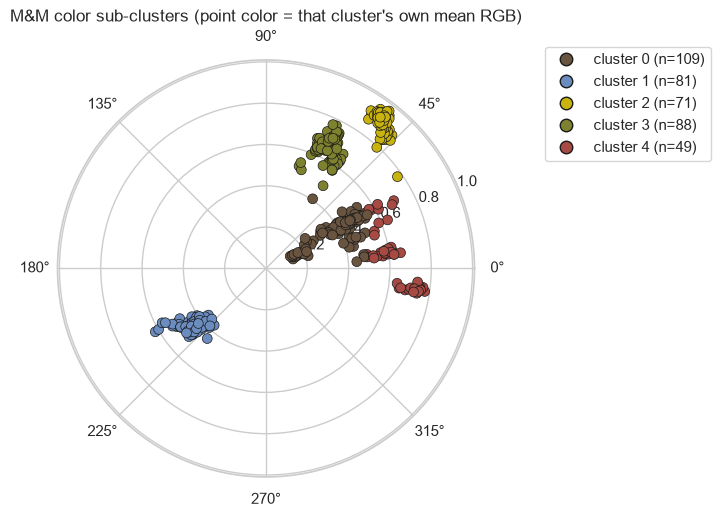

,hue_mean,saturation_mean,R_intensity_mean,G_intensity_mean,B_intensity_mean
color_cluster,,,,,
0,0.08,0.39,104.93,83.54,63.94
1,0.61,0.44,106.18,139.89,190.75
2,0.14,0.90,201.32,179.13,15.42
3,0.17,0.66,125.75,130.14,45.75
4,0.40,0.64,167.89,73.95,68.03


In [22]:
# TODO: set based on the silhouette plot above and how many M&M colors you actually see
N_MM_COLORS = 5

color_kmeans = KMeans(n_clusters=N_MM_COLORS, n_init=10, random_state=0)
mm_df["color_cluster"] = color_kmeans.fit_predict(X_color)

# Color each cluster by its own mean RGB instead of an arbitrary palette, so the plot
# shows what the candy actually looks like rather than an abstract cluster index.
cluster_rgb = (
    mm_df.groupby("color_cluster")[["R_intensity_mean", "G_intensity_mean", "B_intensity_mean"]]
    .mean()
    / 255
)
point_colors = mm_df["color_cluster"].map(cluster_rgb.apply(tuple, axis=1))

theta = mm_df["hue_mean"] * 2 * np.pi
fig, ax = plt.subplots(figsize=(6.5, 5.5), subplot_kw={"projection": "polar"})
ax.scatter(theta, mm_df["saturation_mean"], c=list(point_colors), edgecolors="k", linewidths=0.5, s=50)
ax.set_title("M&M color sub-clusters (point color = that cluster's own mean RGB)")

legend_handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", markerfacecolor=cluster_rgb.loc[c], markeredgecolor="k",
               markersize=9, label=f"cluster {c} (n={(mm_df['color_cluster'] == c).sum()})")
    for c in cluster_rgb.index
]
ax.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.15, 1.05))
plt.tight_layout()
plt.show()

mm_df.groupby("color_cluster")[["hue_mean", "saturation_mean", "R_intensity_mean", "G_intensity_mean", "B_intensity_mean"]].mean().round(2)


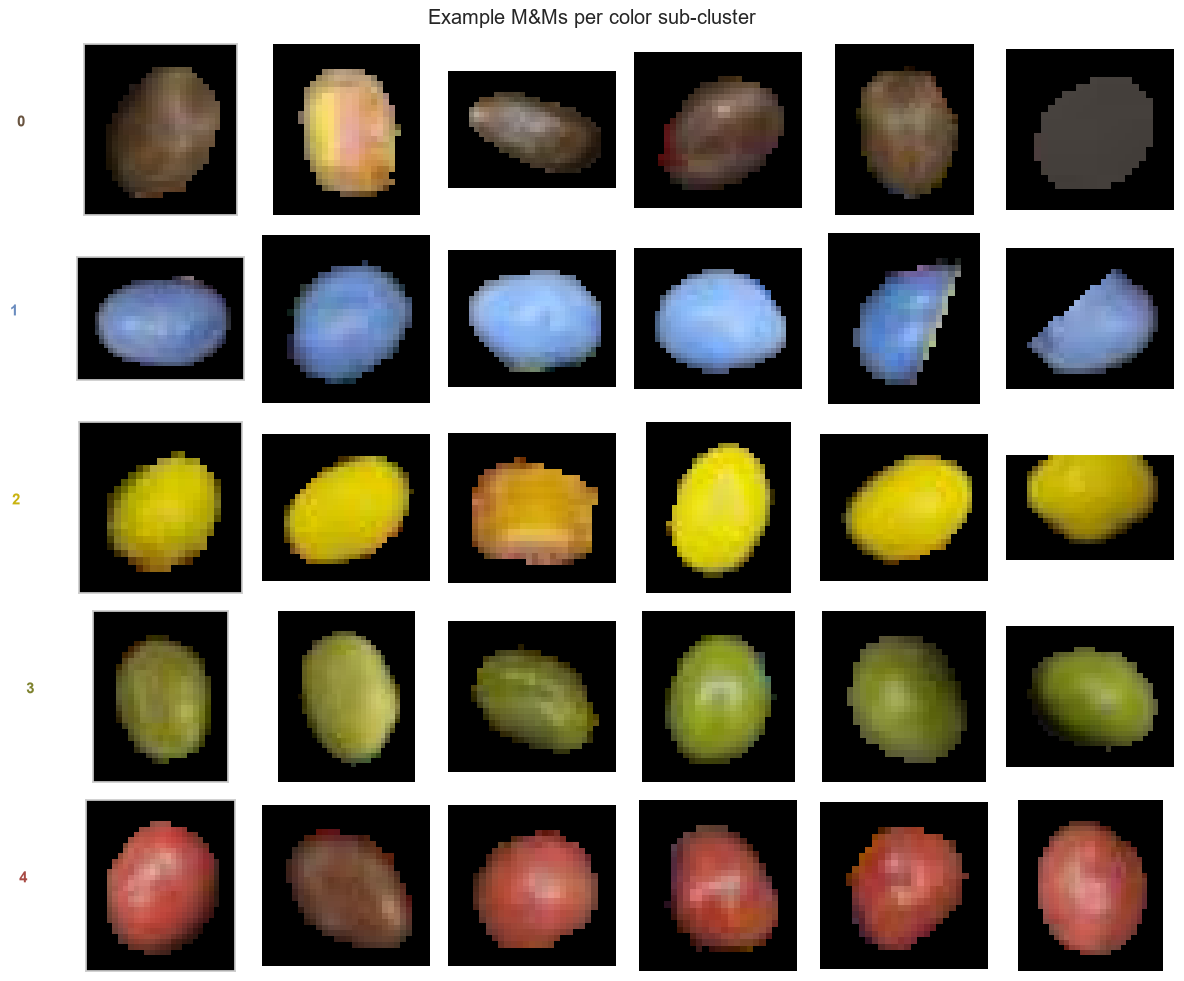

In [23]:
mm_cluster_colors = cluster_rgb.apply(tuple, axis=1).to_dict()
show_examples_by_group(mm_df, "color_cluster", title="Example M&Ms per color sub-cluster",
                        label_colors=mm_cluster_colors)


In [24]:
# Merge the M&M color subtype back into the full feature table (NaN for non-M&Ms)
features_df = features_df.merge(
    mm_df[["candy_id", "color_cluster"]], on="candy_id", how="left"
).rename(columns={"color_cluster": "mm_color_cluster"})

features_df.to_csv("candy_features.csv", index=False)
features_df[["candy_id", "candy_type", "mm_color_cluster"]].head(10)


,candy_id,candy_type,mm_color_cluster
0,IMG_20260703_084754962_1,worm,NaN
1,IMG_20260703_084754962_2,picoballa,NaN
2,IMG_20260703_084754962_3,picoballa,NaN
3,IMG_20260703_084754962_4,picoballa,NaN
4,IMG_20260703_084754962_5,picoballa,NaN
5,IMG_20260703_084754962_6,m&m,4.0
6,IMG_20260703_084754962_7,m&m,3.0
7,IMG_20260703_084754962_8,picoballa,NaN
8,IMG_20260703_084754962_9,worm,NaN
9,IMG_20260703_084754962_10,m&m,0.0


## 9. Next steps / exercises

- **Validate the type clustering**: does `N_TYPES = 3` actually recover 3 clean clusters
  in your photos, or did lighting/segmentation errors create a 4th "junk" cluster (e.g.
  merged candies with abnormally large `area`)? Check the example-crop grid.
- **Check the calibration**: does the M&M diameter sanity check in section 7 come out
  close to 13 mm? If it's consistently off by the same factor for every photo, suspect
  `detect_black_square_bbox` (maybe it's including some of the outer mat, or clipping
  part of the paper); if it's only off for one photo, that photo's crop detection is
  probably the culprit.
- **Compare to blind clustering**: repeat section 7's clustering using *all* features
  (shape + intensity + hue) instead of the hand-picked `TYPE_FEATURES`. Does it still
  recover the same 3 candy types, or does color end up dominating and splitting M&Ms
  into several "types"? This is a good illustration of why feature *selection* — not
  just clustering algorithm choice — determines what structure you find.
- **Pick `N_MM_COLORS` deliberately**: compare the silhouette plot with how many visually
  distinct M&M colors are actually in your photos (e.g. brown, yellow, red, orange,
  green, blue is 6 for classic M&Ms).
- **Extend to worms/picoballa subtypes**: worms and picoballa are multi-colored, so a
  single hue/mean-intensity isn't enough for a fair subtype comparison — you'd need a
  feature that captures the *arrangement* of colors (e.g. mean color of the head vs.
  tail half for worms, since they fade along their long axis; or mean color in
  concentric rings from the center for picoballa's border/fill pattern). This is a good
  extension exercise if you want a finer-grained "cell substate" analogy for those
  classes too.
- **Go supervised**: once you trust the type/subtype clusters, treat them as labels and
  train a classifier (`sklearn.ensemble.RandomForestClassifier` or `sklearn.svm.SVC`)
  with a train/test split, so a *new* photo's candies could be classified without
  re-running KMeans from scratch.
